# Session 5 — Demo 3 — When a line is not enough

**What this demo covers.** Lines are readable, but the world is not always straight. We see a significant line that gets the shape wrong, meet the model that draws steps instead of lines (a decision tree), and its big brother, gradient boosting. Then boosting on the bankruptcy data, compared with Demo 2's logistic regression, and the tools that replace coefficients and p-values when a model has none: built-in feature importance and SHAP.

**Data.** The ALPHA warehouse week (section 1) and the Taiwan bankruptcy data (sections 4–5).

**How to run.** Locally: top to bottom. Colab: uncomment the two `git clone` lines **and** the `%pip install catboost` line in the setup cell: `catboost` is not preinstalled in Colab.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import AutoMinorLocator

# where the data lives, relative to this notebook
WAREHOUSE = Path("../../data/alpha")
BANKRUPTCY = Path("../../data/bankruptcy")

# --- Google Colab? Uncomment these lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# WAREHOUSE = Path("course/data/alpha")
# BANKRUPTCY = Path("course/data/bankruptcy")
# %pip install catboost

POINT_COLOR = "#4a7ebb"
HEALTHY_COLOR = "#4a7ebb"
BANKRUPT_COLOR = "#c0392b"

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

---

## 1. Not everything is a line

Back to the warehouse and to a question from session 4: does the shelf level change how long one pick takes? We need **seconds per pick**, built as in session 4 (plus one new filter below): sort each task's events by time, and take the gap to the previous event with `.diff()`. Smaller is faster.

In [3]:
events = pd.read_parquet(WAREHOUSE / "picking_events.parquet")
topology = pd.read_parquet(WAREHOUSE / "topology.parquet")

events_by_task_time = events.sort_values(["task_id", "event_time"]).copy()
events_by_task_time["pick_seconds"] = (
    events_by_task_time
    .groupby("task_id")["event_time"]   # gaps inside one task only
    .diff()                             # each row minus the one above
    .dt.total_seconds()
)

picks = events_by_task_time[events_by_task_time["event_type"] == "PickCorrectItem"]
picks = picks.merge(
    topology[["cell_id", "cell_level_in_rack"]],
    on="cell_id",
    how="left",
)
picks[["task_id", "pick_seconds", "cell_level_in_rack"]].head(3)

,task_id,pick_seconds,cell_level_in_rack
0,800000001,9.540,5
1,800000001,3.843,3
2,800000001,6.462,1


A few gaps are breaks, not picks (a picker stops for lunch mid-task). We keep picks of up to two minutes, and say how many we drop.

In [4]:
is_kept = picks["pick_seconds"].between(0, 120)
print(
    f"picks: {len(picks):,}   dropped (no gap, or over 120 s): {(~is_kept).sum():,} "
    f"({(~is_kept).mean():.1%})"
)
picks = picks[is_kept]

picks: 145,904   dropped (no gap, or over 120 s): 953 (0.7%)


The line first: seconds per pick against the shelf level (1 = floor, 6 = top).

In [5]:
LEVEL = "cell_level_in_rack"

level_line = sm.OLS(
    picks["pick_seconds"],
    sm.add_constant(picks[[LEVEL]].astype(float)),
).fit()
print(
    f"line: {level_line.params['const']:.2f} s "
    f"+ {level_line.params[LEVEL]:.2f} s per level up\n"
    f"p-value of the slope: {level_line.pvalues[LEVEL]:.1e}\n"
    f"R²: {level_line.rsquared:.3f}"
)

line: 7.47 s + 0.44 s per level up
p-value of the slope: 8.1e-176
R²: 0.005


The line says "each level up adds 0.44 seconds", with a p-value so small it needs scientific notation. Significant. But R² is **0.005**: the line explains almost nothing. Session 4 met this question already, with medians. A least-squares line predicts *averages*, so to judge the line we compare it with averages per level; the median column shows the same shape.

In [6]:
seconds_by_level = (
    picks
    .groupby(LEVEL)["pick_seconds"]
    .agg(["mean", "median", "count"])
    .round(1)
)
seconds_by_level

,mean,median,count
cell_level_in_rack,,,
1,9.3,6.6,31944
2,7.7,5.4,29956
3,7.7,5.4,26138
4,7.5,5.3,21034
5,10.8,7.9,18765
6,11.3,8.2,17114


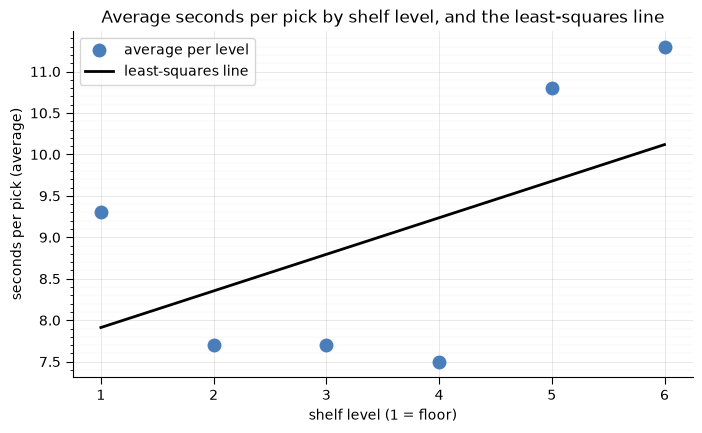

In [7]:
level_axis = np.array([1, 6])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    seconds_by_level.index,
    seconds_by_level["mean"],
    marker="o",
    markersize=9,
    linestyle="none",
    color=POINT_COLOR,
    label="average per level",
)
ax.plot(
    level_axis,
    level_line.params["const"] + level_line.params[LEVEL] * level_axis,
    color="black",
    linewidth=2,
    label="least-squares line",
)
ax.set_title("Average seconds per pick by shelf level, and the least-squares line")
ax.set_xlabel("shelf level (1 = floor)")
ax.set_ylabel("seconds per pick (average)")
ax.legend()
make_ax_better(ax, minor="y")
plt.show()

**The real shape is a valley**, the same one session 4 found with medians. Levels 2 to 4, at arm's height, are the fastest. The floor is slower (bend down), and the top two levels are slowest (reach, or a step-ladder). The line sees only "higher is a bit slower" and misses the shape completely.

**Significant is not the same as right.** A p-value tells you the slope isn't zero; it doesn't tell you a straight line is the right shape. This is the first Gauss–Markov condition from Demo 1, *linearity*, broken in plain sight. The tiny R² was the hint.

## 2. A tree: steps instead of a line

A **decision tree** is nested if-else. It asks yes/no questions about a feature ("level 4 or lower?") and gives one answer per group. It draws **steps**, not a line. `scikit-learn` has one for numbers (`DecisionTreeRegressor`); `max_depth=2` allows two questions in a row, so at most four groups, and `export_text` prints the questions the tree chose. Like every scikit-learn model it takes features first, `.fit(X, y)`: the other way round from `sm.OLS(y, X)` two cells up.

In [8]:
from sklearn.tree import DecisionTreeRegressor, export_text

level_tree = DecisionTreeRegressor(max_depth=2)
level_tree.fit(picks[[LEVEL]], picks["pick_seconds"])

# the tree's questions, printed as if-else
print(export_text(level_tree, feature_names=[LEVEL], decimals=1))

|--- cell_level_in_rack <= 4.5
|   |--- cell_level_in_rack <= 1.5
|   |   |--- value: [9.3]
|   |--- cell_level_in_rack >  1.5
|   |   |--- value: [7.6]
|--- cell_level_in_rack >  4.5
|   |--- cell_level_in_rack <= 5.5
|   |   |--- value: [10.8]
|   |--- cell_level_in_rack >  5.5
|   |   |--- value: [11.3]



Read it like code: "if the level is 4.5 or lower: if it's 1.5 or lower → floor, else → middle; otherwise…". A tree cuts halfway between two values it has seen, so 4.5 means "between level 4 and level 5". The tree found the groups by itself. On the same chart as the line:

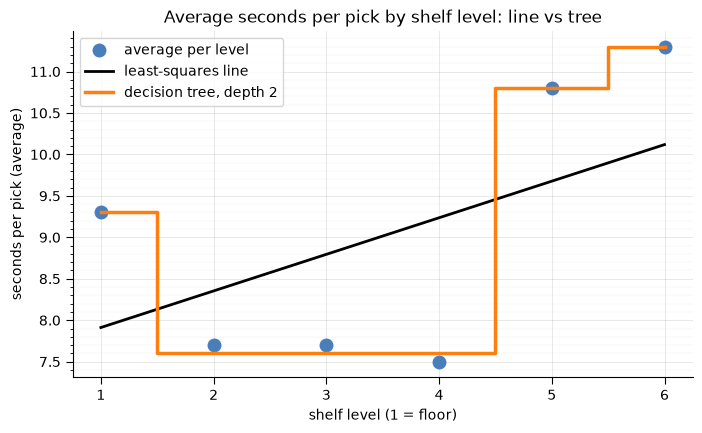

,mean,median,count,tree
cell_level_in_rack,,,,
1,9.3,6.6,31944,9.3
2,7.7,5.4,29956,7.6
3,7.7,5.4,26138,7.6
4,7.5,5.3,21034,7.6
5,10.8,7.9,18765,10.8
6,11.3,8.2,17114,11.3


In [9]:
levels = pd.DataFrame({LEVEL: [1, 2, 3, 4, 5, 6]})
seconds_by_level["tree"] = level_tree.predict(levels).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    seconds_by_level.index,
    seconds_by_level["mean"],
    marker="o",
    markersize=9,
    linestyle="none",
    color=POINT_COLOR,
    label="average per level",
)
ax.plot(
    level_axis,
    level_line.params["const"] + level_line.params[LEVEL] * level_axis,
    color="black",
    linewidth=2,
    label="least-squares line",
)
ax.step(
    seconds_by_level.index,
    seconds_by_level["tree"],
    where="mid",
    color="tab:orange",
    linewidth=2.5,
    label="decision tree, depth 2",
)
ax.set_title("Average seconds per pick by shelf level: line vs tree")
ax.set_xlabel("shelf level (1 = floor)")
ax.set_ylabel("seconds per pick (average)")
ax.legend()
make_ax_better(ax, minor="y")
plt.show()

seconds_by_level

The tree follows the valley. The price: a tree has no single coefficient to read. "0.44 seconds per level" was wrong, but it was one number; the tree is a set of rules.

## 3. ⏭ 🧪 Toy example: the same for classes, a ring

A **made-up** case where no straight line can work: class A sits inside a circle, class B around it. Everything named `toy_…` in this section is made up. The points are generated from an angle and a distance to the centre (`toy_rng.uniform` draws random numbers evenly between two limits, `np.cos` / `np.sin` turn angle and distance into x and y, `np.repeat` writes the class labels: 200 zeros, then 200 ones). Only the picture matters.

In [10]:
toy_rng = np.random.default_rng(3)
toy_angle = toy_rng.uniform(0, 2 * np.pi, 400)
toy_radius = np.concatenate([
    toy_rng.uniform(0, 1.0, 200),     # class A: inside
    toy_rng.uniform(1.5, 2.5, 200),   # class B: a ring around it
])
toy_ring = pd.DataFrame({
    "x": toy_radius * np.cos(toy_angle),
    "y": toy_radius * np.sin(toy_angle),
    "is_outside": np.repeat([0, 1], 200),
})
toy_ring.head(3)

,x,y,is_outside
0,0.318671,0.190220,0
1,0.021964,0.264429,0
2,0.117973,-0.353427,0


We fit three models and colour the whole square by the class each model would give. To do that we make a fine grid of points covering the square (`np.meshgrid` builds it), ask the model about every grid point, and paint it with `ax.contourf`.

- **Logistic regression** (Demo 2): one straight line.
- **A decision tree**, depth 4 (`DecisionTreeClassifier`, the classes version of the tree above): steps.
- **Gradient boosting** (`CatBoostClassifier`, next section): many small trees added together.

In the drawing code, `zip(axes, toy_ring_models.items())` walks through the three panels and the three models in pairs, the same idea as `enumerate` in the primer. `.ravel()` flattens the grid into one long column, `.reshape` folds the answers back into the grid's shape, `ax.set_aspect("equal")` keeps circles round, and `fig.suptitle` puts one title over all panels.

In [11]:
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

toy_ring_features = toy_ring[["x", "y"]]
toy_ring_target = toy_ring["is_outside"]

toy_ring_models = {
    "logistic regression": LogisticRegression(),
    "decision tree, depth 4": DecisionTreeClassifier(max_depth=4),
    "gradient boosting": CatBoostClassifier(iterations=200, verbose=0, random_seed=42),
}
for model in toy_ring_models.values():
    model.fit(toy_ring_features, toy_ring_target)

toy_axis = np.linspace(-3, 3, 200)
toy_grid_x, toy_grid_y = np.meshgrid(toy_axis, toy_axis)
toy_grid = pd.DataFrame({"x": toy_grid_x.ravel(), "y": toy_grid_y.ravel()})

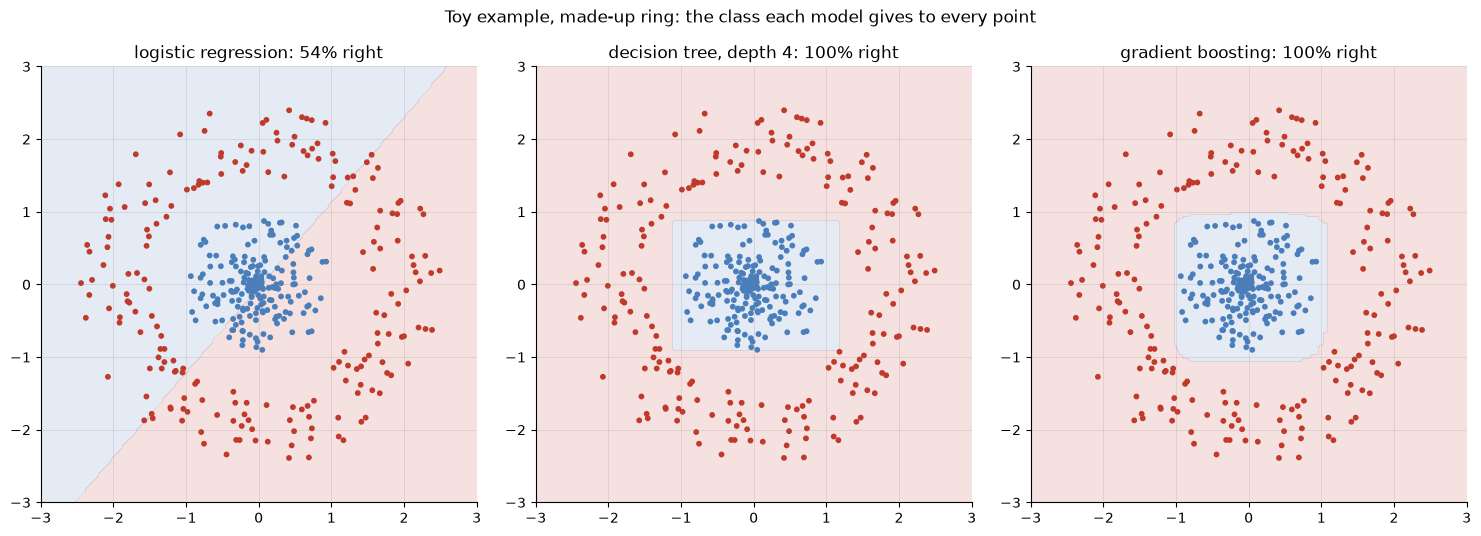

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, toy_ring_models.items()):
    toy_grid_class = model.predict(toy_grid).reshape(toy_grid_x.shape)
    ax.contourf(
        toy_grid_x,
        toy_grid_y,
        toy_grid_class,
        levels=[-0.5, 0.5, 1.5],
        colors=[HEALTHY_COLOR, BANKRUPT_COLOR],
        alpha=0.15,
    )
    ax.scatter(
        toy_ring["x"],
        toy_ring["y"],
        c=np.where(toy_ring_target == 1, BANKRUPT_COLOR, HEALTHY_COLOR),
        s=10,
    )
    accuracy = (model.predict(toy_ring_features).ravel() == toy_ring_target).mean()
    ax.set_title(f"{name}: {accuracy:.0%} right")
    ax.set_aspect("equal")
    make_ax_better(ax)

fig.suptitle(
    "Toy example, made-up ring: the class each model gives to every point",
    y=1.02,
)
plt.tight_layout()
plt.show()

The logistic regression can only cut the square with one straight line, so it gets about half the points right: a coin flip. The tree carves a box out of steps. Boosting, many small trees added together, rounds the box's corners toward the circle.

One warning about the 100%: these scores are on the same points the models learned from. Section 4 shows why that is not a grade; here it only shows what shapes each model can draw.

## 4. Boosting on the bankruptcy data

**Gradient boosting** builds hundreds of small trees *in a row*. Each new tree looks at the mistakes of all the trees before it and tries to fix them. Three hundred small fixes later you have the model that wins most competitions on tables. Two practical facts:

- it needs **no standardization**: a tree only asks "above or below this cut?", and units don't matter for that;
- it has **no coefficients**, so no p-values either. Section 5 shows what replaces them.

**Back to the real data.** Every model below follows the schema from Demo 1: `.fit(X_train, y_train)` gives a fitted model, `.predict(X_test)` gives its guesses for firms it has never seen. First, Demo 2's setup again in one cell: load, clean, split, the five ratios standardized, the two logistic regressions. Then Demo 2's counting function, this time taking the true classes as well, so it works for train and test.

In [13]:
from sklearn.model_selection import train_test_split

firms = pd.read_csv(BANKRUPTCY / "taiwan_bankruptcy.csv")
firms.columns = firms.columns.str.strip()
firms = firms.drop(columns=["Net Income Flag"])

y = firms["Bankrupt?"]
X = firms.drop(columns=["Bankrupt?"])

# the same split as Demo 2, so every model faces the same exam
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

FIVE_RATIOS = [
    "Working Capital to Total Assets",
    "Retained Earnings to Total Assets",
    "ROA(C) before interest and depreciation before interest",
    "Total Asset Turnover",
    "Debt ratio %",
]
train_mean = X_train[FIVE_RATIOS].mean()
train_std = X_train[FIVE_RATIOS].std()
five_train = (X_train[FIVE_RATIOS] - train_mean) / train_std
five_test = (X_test[FIVE_RATIOS] - train_mean) / train_std

five_logit = LogisticRegression().fit(five_train, y_train)
weighted_logit = LogisticRegression(class_weight="balanced").fit(five_train, y_train)
print(
    f"{X.shape[1]} feature columns, "
    f"{len(X_test):,} test firms, {y_test.sum()} bankrupt"
)

94 feature columns, 2,046 test firms, 66 bankrupt


In [14]:
def count_verdicts(called_bankrupt, actually_bankrupt):
    """Accuracy, caught bankruptcies and false alarms of 0/1 calls."""
    called_bankrupt = np.asarray(called_bankrupt).ravel() == 1
    actually_bankrupt = np.asarray(actually_bankrupt) == 1
    return {
        "accuracy": round(float((called_bankrupt == actually_bankrupt).mean()), 3),
        "caught": int((called_bankrupt & actually_bankrupt).sum()),
        "missed": int((~called_bankrupt & actually_bankrupt).sum()),
        "false_alarms": int((called_bankrupt & ~actually_bankrupt).sum()),
    }

**The AI-boilerplate moment.** The prompt:

> You are a Python ML engineer. Train a CatBoostClassifier on a pandas DataFrame: binary target `y_train`, 94 numeric features `X_train`. Use balanced class weights, 300 iterations, `random_seed=42`, silent. Return only the code.

The returned code, read line by line before running. `auto_class_weights="Balanced"` is CatBoost's name for the class weights from Demo 2.

In [15]:
# — code returned by the assistant; read every line, then run —
boosting_model = CatBoostClassifier(
    iterations=300,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
)
boosting_model.fit(X_train, y_train)

CatBoostClassifier(auto_class_weights='Balanced', iterations=300, random_seed=42, verbose=0)

The first check the assistant can't do for you: how does it score on the firms it **learned from**, and on the firms it has **never seen**?

In [16]:
print("train:", count_verdicts(boosting_model.predict(X_train), y_train))
print("test: ", count_verdicts(boosting_model.predict(X_test), y_test))

train: {'accuracy': 1.0, 'caught': 154, 'missed': 0, 'false_alarms': 2}
test:  {'accuracy': 0.964, 'caught': 34, 'missed': 32, 'false_alarms': 41}


On the training firms the model catches **every single bankruptcy** (accuracy 1.0 is rounded: two healthy firms were flagged). It has seen these firms with their answers, and 300 trees are enough to memorise them. That is called **overfitting**. On new firms it catches about half. **The train number is not a grade**; only the test number is. This is why we split before everything else.

Now all four side by side, on the test firms:

In [17]:
everyone_healthy = np.zeros(len(y_test))

comparison = pd.DataFrame(
    [
        count_verdicts(everyone_healthy, y_test),
        count_verdicts(five_logit.predict(five_test), y_test),
        count_verdicts(weighted_logit.predict(five_test), y_test),
        count_verdicts(boosting_model.predict(X_test), y_test),
    ],
    index=[
        "everyone healthy",
        "logistic, five ratios",
        "logistic + class weights",
        "boosting + class weights, all ratios",
    ],
)
comparison

,accuracy,caught,missed,false_alarms
everyone healthy,0.968,0,66,0
"logistic, five ratios",0.969,12,54,9
logistic + class weights,0.863,57,9,272
"boosting + class weights, all ratios",0.964,34,32,41


Look at the boosting row: its accuracy is **below the "everyone healthy" line**, and yet it catches about half of the bankruptcies with far fewer false alarms than the weighted logistic regression. The weighted logistic regression catches more, but raises many more false alarms.

A simple model that every harder one must beat is called a **baseline**. Tonight the logistic regression on five ratios plays that role; in HW2 it is your Part 3 logistic regression.

**Who wins?** Nobody can say yet. It depends on what a missed bankruptcy costs compared with a false alarm, and accuracy can't see that. Session 6 gives you that price, and the metrics to go with it.

## 5. Instead of coefficients: importance and SHAP

A logistic regression gave us one weight and one p-value per ratio. Boosting has neither. Two replacements.

**Built-in importance.** `get_feature_importance()` says how much, on average, the model's predictions rely on each feature. The numbers add up to 100, so they read as "shares of attention".

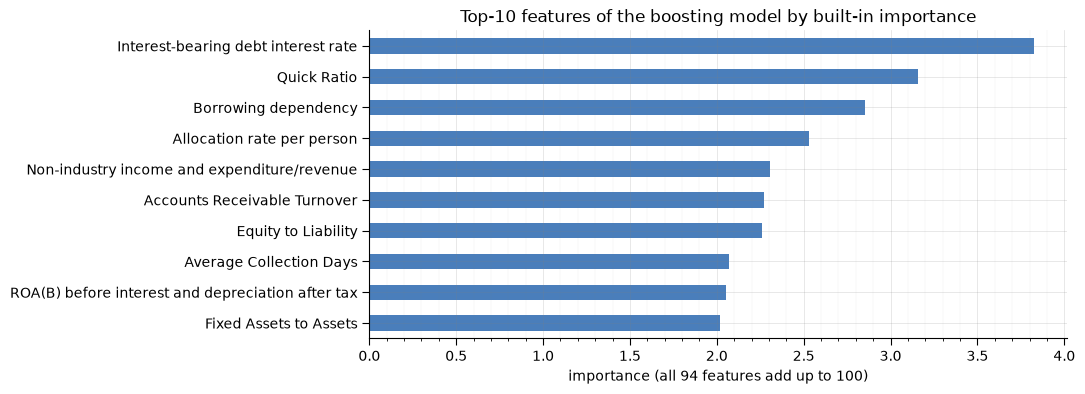

the top 10 hold 25 of 100; the other 84 features share the rest


In [18]:
importance = pd.Series(
    boosting_model.get_feature_importance(),
    index=X.columns,
).sort_values(ascending=False)

top_ten = importance.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
top_ten.plot(kind="barh", ax=ax, color=POINT_COLOR)
ax.set_title("Top-10 features of the boosting model by built-in importance")
ax.set_xlabel("importance (all 94 features add up to 100)")
ax.set_ylabel("")
make_ax_better(ax, minor="x")
plt.show()

print(
    f"the top 10 hold {importance.head(10).sum():.0f} of 100; "
    f"the other {len(importance) - 10} features share the rest"
)

Where are Altman's five? Not on top. But look at the *families*: the interest rate on debt and borrowing dependency (leverage and debt service), Quick Ratio (liquidity), a ROA column (profitability). **Same economics, different representatives**: with 94 related ratios, the model picks its favourite cousins. Read families, not single names. And before you quote a name from this list in a memo, look at its `describe()`: several of these columns hide the scale surprise from Demo 2's Try it 1.

Importance answers "what does the model use in general?". A credit committee asks something else: **why this firm?**

**SHAP** splits one firm's verdict among its features: which ratio pushed the firm toward "bankrupt", which pulled it back, and how hard. The numbers live on the scale of the score $z$ from Demo 2, *before* the sigmoid (this scale is called **log-odds**), not in percent: start from the model's average score, add up all the pushes, and you land on this firm's score; the sigmoid turns it into its probability. CatBoost computes them itself; `Pool` is its container for "features plus answers", and the last column of the result is that average guess, so we drop it.

In [19]:
from catboost import Pool

shap_with_baseline = boosting_model.get_feature_importance(
    Pool(X_test, y_test),
    type="ShapValues",
)
shap_table = pd.DataFrame(shap_with_baseline[:, :-1], columns=X.columns)

verdicts = pd.DataFrame({
    "bankrupt_proba": boosting_model.predict_proba(X_test)[:, 1],
    "actually_bankrupt": y_test.to_numpy(),
})
flagged_row = (
    verdicts[verdicts["actually_bankrupt"] == 1]
    .sort_values("bankrupt_proba", ascending=False)
    .index[0]
)
cleared_row = (
    verdicts[verdicts["actually_bankrupt"] == 0]
    .sort_values("bankrupt_proba", ascending=True)
    .index[0]
)
verdicts.loc[[flagged_row, cleared_row]].round(3)

,bankrupt_proba,actually_bankrupt
248,0.984,1
1064,0.000,0


**All test firms at once.** Before reading single firms, one picture shows every SHAP value of the ten most important ratios. It is the standard SHAP picture, often called a *beeswarm*:

- **one row per ratio**, the most important on top (ranked by mean |SHAP|: drop the sign, then average, the same move as Demo 1's average miss);
- **one dot per test firm** in every row;
- **left–right = that firm's SHAP value** for the ratio: right of the grey line pushes toward bankruptcy, left pulls toward healthy;
- **colour = the firm's value of the ratio**, from blue (among the lowest of the test firms) to red (among the highest). **In this one picture red and blue mean the ratio's value, not the class.**

Up and down inside a row means nothing: the dots are spread a little at random so that 2,046 of them don't sit on one line.

New tools in the code: `.tail(10)` is the mirror of `.head(10)`: the last ten rows, here the ten biggest after sorting; `enumerate` from the primer walks through the ratios with their row number; `.rank(pct=True)` turns each value into its position among the test firms, from 0 (lowest) to 1 (highest), which also ignores the few values in the billions; `c=` and `cmap="coolwarm"` colour each dot by that position; `fig.colorbar` draws the colour key and `.set_label` names it; `ax.set_yticks` and `ax.set_yticklabels` put the ratio names on the rows.

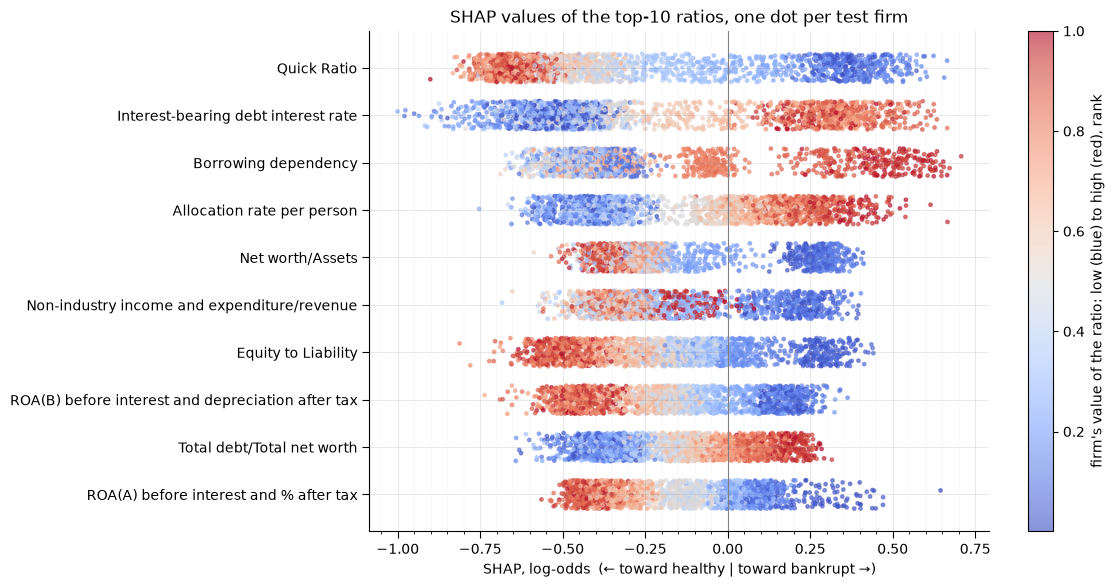

In [20]:
# rows numbered 0, 1, 2... like shap_table
test_firms = X_test.reset_index(drop=True)

# ten ratios with the biggest typical push; the smallest ends up at the bottom
top_shap_ratios = shap_table.abs().mean().sort_values().tail(10).index
spread_rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(10, 6.5))
for row_number, ratio in enumerate(top_shap_ratios):
    value_position = test_firms[ratio].rank(pct=True)
    vertical_spread = spread_rng.uniform(-0.3, 0.3, len(test_firms))
    dots = ax.scatter(
        shap_table[ratio],
        row_number + vertical_spread,
        c=value_position,
        cmap="coolwarm",
        s=6,
        alpha=0.6,
    )
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_yticks(range(len(top_shap_ratios)))
ax.set_yticklabels(top_shap_ratios)
colour_key = fig.colorbar(dots, ax=ax)
colour_key.set_label("firm's value of the ratio: low (blue) to high (red), rank")
ax.set_title("SHAP values of the top-10 ratios, one dot per test firm")
ax.set_xlabel("SHAP, log-odds  (← toward healthy | toward bankrupt →)")
make_ax_better(ax, minor="x")
plt.show()

Read one row first. **Quick Ratio:** blue dots (little quick assets) sit on the right, pushing toward bankruptcy; red dots (plenty of liquidity) sit on the left, pulling toward healthy. Low liquidity is dangerous, exactly as a financier would say.

Now the whole picture, row by row, as families:

- **Leverage and cost of debt** (interest rate on debt, borrowing dependency, total debt to net worth): **red on the right**. More debt, and dearer debt, push toward bankruptcy.
- **Cushion and profitability** (net worth to assets, equity to liability, both ROA columns): **blue on the right**. Too little equity or profit pushes toward bankruptcy.
- **One honest exception:** `Allocation rate per person` is red on the right too, but it has no clear finance meaning. Report it as "the model uses it", not as a finding.

This picture is the boosting model's answer to Demo 2's coefficient table: *size* (how wide a row spreads) and *direction* (which colour sits on which side), for a model that has no coefficients at all. The order differs a little from the built-in importance above: they are two different measures of "important", and both are worth a look.

Two firms: the actual bankrupt the model flags hardest, and the healthy firm it clears most confidently. For each, the five biggest pushes, in Demo 2's colours: red pushes toward bankruptcy, blue pulls toward healthy. `.tail(5)` works as above: the five biggest after sorting.

Flagged bankrupt firm: five bars cover 19% of its total push
Cleared healthy firm: five bars cover 22% of its total push


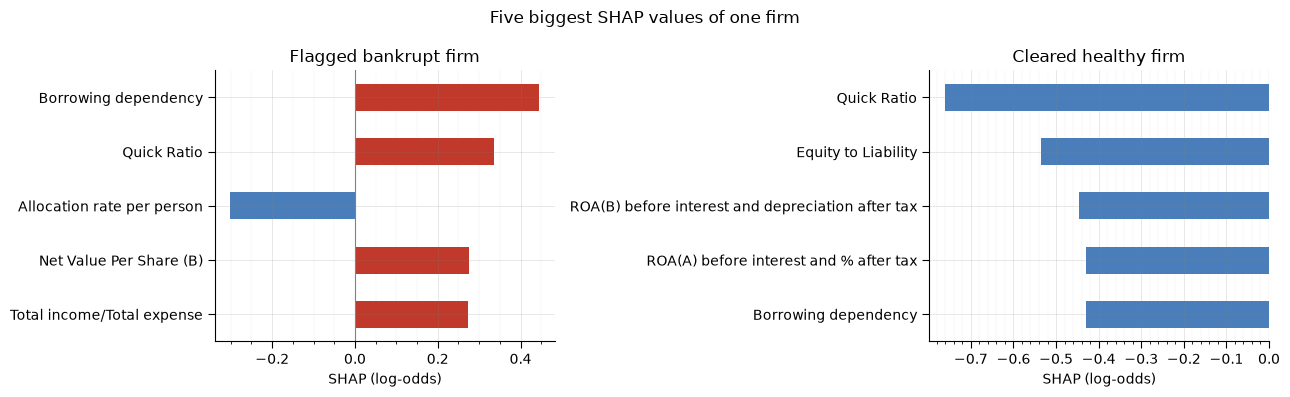

In [21]:
def draw_top_five_shap(firm_row, ax, title):
    """Draw one firm's five biggest SHAP values; return them."""
    firm_shap = shap_table.loc[firm_row]
    biggest_names = firm_shap.abs().sort_values().tail(5).index
    biggest_five = firm_shap[biggest_names]

    bar_colors = np.where(biggest_five > 0, BANKRUPT_COLOR, HEALTHY_COLOR)
    biggest_five.plot(kind="barh", ax=ax, color=bar_colors)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("SHAP (log-odds)")
    ax.set_ylabel("")
    make_ax_better(ax, minor="x")

    covered_share = biggest_five.abs().sum() / firm_shap.abs().sum()
    print(f"{title}: five bars cover {covered_share:.0%} of its total push")
    return biggest_five


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
flagged_top = draw_top_five_shap(flagged_row, axes[0], "Flagged bankrupt firm")
cleared_top = draw_top_five_shap(cleared_row, axes[1], "Cleared healthy firm")
fig.suptitle("Five biggest SHAP values of one firm")
plt.tight_layout()
plt.show()

A bar says *which* ratio pushed. Before writing a sentence for a committee, check *what value* the firm had: for each bar, the firm's value and the share of all firms below it.

In [22]:
def print_values_behind_bars(firm_row, top_bars):
    """For each bar: the firm's value and the share of all firms below it."""
    biggest_first = top_bars.abs().sort_values(ascending=False).index
    for feature in biggest_first:
        value = test_firms.loc[firm_row, feature]
        share_lower = (X[feature] < value).mean()
        print(f"  {feature}: {value:.4f}, {share_lower:.0%} of firms are lower")


print("FLAGGED")
print_values_behind_bars(flagged_row, flagged_top)
print("CLEARED")
print_values_behind_bars(cleared_row, cleared_top)

FLAGGED
  Borrowing dependency: 0.6690, 100% of firms are lower
  Quick Ratio: 0.0013, 4% of firms are lower
  Allocation rate per person: 0.0056, 36% of firms are lower
  Net Value Per Share (B): 0.1287, 0% of firms are lower
  Total income/Total expense: 0.0020, 4% of firms are lower
CLEARED
  Quick Ratio: 0.0120, 74% of firms are lower
  Equity to Liability: 0.0789, 88% of firms are lower
  ROA(B) before interest and depreciation after tax: 0.6024, 84% of firms are lower
  ROA(A) before interest and % after tax: 0.6071, 84% of firms are lower
  Borrowing dependency: 0.3704, 28% of firms are lower


Now read them aloud, committee-style.

First, a rounding check, as with p = 0.0 in session 4: 100% and 0% above are rounded. Only five firms in the data depend on borrowing more than the flagged one, and only 15 have a lower book value per share. Check the count before you write "the most".

*Flagged: only five firms in the data depend on borrowed money more. It has almost no quick assets (bottom 4%), and only 15 firms have a lower book value per share. Its income relative to its expenses is in the bottom 4%. Leverage, liquidity and profitability all point the same way.*

*Cleared: plenty of quick assets (top quarter) and far more equity than liabilities (top 12%). Profitability is in the top fifth on both ROA columns, and borrowing is modest.*

One bar in the flagged firm pulls the other way: `Allocation rate per person`, a column with no clear finance meaning. Say so in the memo instead of inventing a story.

That is what SHAP gives a credit committee: not "the model said so", but which ratios drove this verdict, checked against the firm's actual numbers. Five bars are only part of the story (see the coverage lines above), so say "the main drivers", not "the reasons".

## 6. SHAP in one page: what it is and how to live with it

**Where it comes from.** In 1953 the economist Lloyd Shapley (Nobel prize in economics, 2012) solved a question from game theory: several players win a prize together; how do you split it fairly, by what each one really contributed? His answer, the *Shapley value*, averages each player's extra contribution over every order in which the players could join. In 2017 Scott Lundberg and Su-In Lee applied it to models: the players are the features, the prize is one prediction. They called it **SHAP**, *SHapley Additive exPlanations*.

**Two views of the same numbers.**

- *Local*: one firm, one verdict, split among its ratios (the bar charts above). This is what a credit committee asks for.
- *Global*: all firms together. Mean |SHAP| ranks the ratios; the beeswarm also shows the direction.

**How to live with it: six rules.**

1. **SHAP explains the model, not the world.** "The model pushes firms with high borrowing toward bankruptcy" is a statement about the model. Whether borrowing *causes* bankruptcy is a different question that SHAP can't answer.
2. **Twins split the credit here too.** Correlated ratios share the push between them, as coefficients did in Demo 1 and Demo 2. Read families, not single names.
3. **Know the units.** Values are in log-odds, the score before the sigmoid. They add up: average score + all pushes = the firm's score. They are not percentages.
4. **Explain firms the model has not memorised.** Compute SHAP on the test firms, and check the ratio values behind every bar you quote.
5. **An explanation is only as good as the model.** Check the test numbers first; a model that is wrong explains its wrong answers just as confidently.
6. **Watch the scale.** A few values in the billions stretch any axis; ranks (as in the beeswarm) or `describe()` first.

**Tools.** CatBoost, XGBoost and LightGBM compute SHAP themselves, as we did with `type="ShapValues"`. The `shap` package (`%pip install shap`) draws the standard pictures for almost any model: `shap.plots.beeswarm` for the picture above, `shap.plots.waterfall` for one firm's verdict step by step.

**Read more.**

- The instructor's telegram posts (in Russian): [what SHAP is and why it borrows from game theory](https://t.me/shumpy_channel/21), and [how SHAP is computed for tree models](https://t.me/shumpy_channel/22).
- Christoph Molnar, *Interpretable Machine Learning*, [chapter "SHAP"](https://christophm.github.io/interpretable-ml-book/shap.html): the clearest free explanation, with pictures.
- [SHAP documentation: the beeswarm plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html), with the same picture on other data.
- Lundberg and Lee, [*A Unified Approach to Interpreting Model Predictions*](https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions), NeurIPS 2017: the original paper.

## Try it yourself

1. Fit the shelf-level tree with `max_depth=1`. Which single question does it ask? Is that a sensible one-sentence rule for a warehouse manager?
2. Train the boosting model **without** class weights. How many bankruptcies does it catch on the test firms now? What happened to its train numbers?
3. Explain the model's second most confident flag: `.index[1]` instead of `.index[0]`. Do the bars and the values tell a coherent story?

In [23]:
# your turn

## Recap

- **Significant is not the same as right.** Shelf levels: the line's p-value is tiny, but the real shape is a valley. A tiny R² is a hint to look at the shape.
- **A decision tree** is nested if-else and draws steps. **Boosting** adds up hundreds of small trees, each fixing the previous ones' mistakes. Neither needs standardization.
- **The train number is not a grade:** boosting catches every bankruptcy it learned from, about half of the new ones.
- With class weights, boosting and logistic regression win in different ways. Choosing needs the price of each mistake: session 6.
- **No coefficients, no p-values:** read built-in importance for the model as a whole, the SHAP beeswarm for size *and* direction across all firms, and SHAP bars for one firm, with the values behind the bars.
- SHAP explains the model, not the world; it is in log-odds; twins share the credit (section 6 has the one-page reference and links).